In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [69]:
mfdata_DIR='E:/Debjyoti/Project Work/GPM Data/Delhi/Data 13-06-17/gpm*'
df=xr.open_mfdataset(mfdata_DIR, parallel=True, engine= 'netcdf4')

In [70]:
df

<xarray.Dataset>
Dimensions:           (time: 48, lon: 246, lat: 331)
Coordinates:
  * time              (time) datetime64[ns] 2017-06-13 ... 2017-06-13T23:30:00
  * lon               (lon) float32 71.75 71.85 71.95 ... 96.05 96.15 96.25
  * lat               (lat) float32 1.85 1.95 2.05 2.15 ... 34.65 34.75 34.85
Data variables:
    precipitationCal  (time, lon, lat) float32 dask.array<chunksize=(1, 246, 331), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH/06;\n...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=6a;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR.MS.MRG.3IMERG.20170613-S00...
    history_L34RS:                          'Created by L34RS v1.4.3 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [71]:
###### cropping data to required lat-lon extent
min_lon = 75.50
min_lat = 26.50
max_lon = 79.00
max_lat = 30.00

df1 = df.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))

In [72]:
pricp=df1.precipitationCal
time=df1.time

In [73]:
#avgeraging over lat lon
pricp_avg=pricp.mean(dim=['lat','lon'])

In [74]:
#conversation from half-hourly precipitation to hourly precipitation
pricp_avg1=[]  #hourly precipitation
for i in range(0 ,48,2):
    pricp_avg1.append(pricp_avg[i]+pricp_avg[i+1])
    

In [75]:
pricp_avg1=np.asarray(pricp_avg1)

In [76]:
pricp_avg1.shape

(24,)

In [77]:
#arranging time step
time= np.arange (0,24)
time.shape
print (time)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


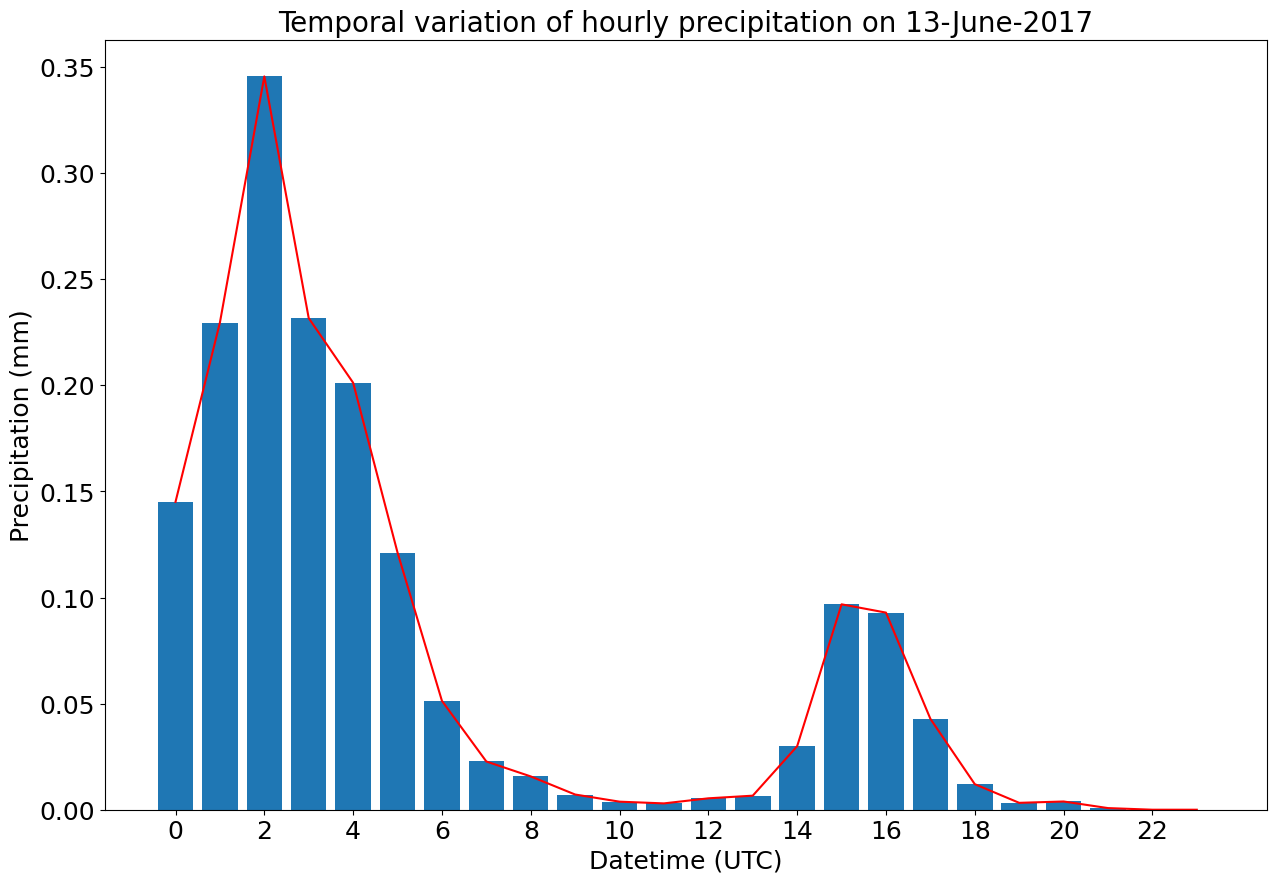

In [78]:
### plotting the temporal variation
path='E:/Debjyoti/Project Work/Images/Delhi/2017/Dt13-06-17'
import os
if not os.path.exists(path):
    os.makedirs(path)
    
plt.figure(figsize=(15,10))
plt.bar(time,pricp_avg1)
plt.plot(time,pricp_avg1, color="red")
plt.xticks(np.arange(0,24, step=2), fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('Datetime (UTC)', fontsize=18)
plt.ylabel('Precipitation (mm)', fontsize=18)
plt.title('Temporal variation of hourly precipitation on 13-June-2017', fontsize=20 )
plt.savefig('E:/Debjyoti/Project Work/Images/Delhi/2017/Dt13-06-17/temporal variation of hourly rainfall.tiff')